In [ ]:
# ============================
# BLOCK 1: SETUP + METRICS
# ============================

import os, time, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import Xception
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import *
from sklearn.manifold import TSNE
from scipy.stats import ttest_rel

# CONFIG
# Dataset path is configurable via the PMRAM_DATASET_PATH environment variable
# so the notebook is not tied to a single hard-coded Kaggle location. The
# default below is the path used for the reported run.
DEFAULT_DATASET_PATH = "/kaggle/input/datasets/orvile/pmram-bangladeshi-brain-cancer-mri-dataset/PMRAM Bangladeshi Brain Cancer - MRI Dataset/PMRAM Bangladeshi Brain Cancer - MRI Dataset/Raw Data/Raw"
DATASET_PATH = os.environ.get("PMRAM_DATASET_PATH", DEFAULT_DATASET_PATH)
SYNTHETIC_DIR = os.environ.get("SYNTHETIC_DIR", "/kaggle/working/synthetic_gan")

IMG_SIZE_GAN = (128,128)
IMG_SIZE_XCEP = (299,299)
LATENT_DIM = 100
BATCH_SIZE = 32
EPOCHS_GAN = 1500
EPOCHS_FE = 10
EPOCHS_FT = 20
N_SPLITS = 5
SEED = 42

os.makedirs(SYNTHETIC_DIR, exist_ok=True)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---------------------------
# ADVANCED METRICS
# ---------------------------
def compute_per_class_metrics(y_true, y_pred, y_probs, classes):
    results = {}
    for i, cls in enumerate(classes):
        y_true_bin = (y_true == i).astype(int)
        y_pred_bin = (y_pred == i).astype(int)

        TP = np.sum((y_true_bin==1)&(y_pred_bin==1))
        TN = np.sum((y_true_bin==0)&(y_pred_bin==0))
        FP = np.sum((y_true_bin==0)&(y_pred_bin==1))
        FN = np.sum((y_true_bin==1)&(y_pred_bin==0))

        results[cls] = {
            "Sensitivity": TP/(TP+FN+1e-7),
            "Specificity": TN/(TN+FP+1e-7),
            "Precision": precision_score(y_true_bin,y_pred_bin),
            "F1": f1_score(y_true_bin,y_pred_bin),
            "AUC": roc_auc_score(y_true_bin,y_probs[:,i])
        }
    return pd.DataFrame(results).T

def plot_roc(y_true, y_probs, classes):
    plt.figure()
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve((y_true==i).astype(int), y_probs[:,i])
        plt.plot(fpr, tpr, label=cls)
    plt.legend(); plt.title("ROC Curve"); plt.show()

def plot_pr(y_true, y_probs, classes):
    plt.figure()
    for i, cls in enumerate(classes):
        p,r,_ = precision_recall_curve((y_true==i).astype(int), y_probs[:,i])
        plt.plot(r,p,label=cls)
    plt.legend(); plt.title("PR Curve"); plt.show()

def compute_ece(y_true, y_probs):
    conf = np.max(y_probs,axis=1)
    pred = np.argmax(y_probs,axis=1)
    acc = (pred==y_true)

    bins = np.linspace(0,1,11)
    ece=0
    for i in range(10):
        mask = (conf>=bins[i])&(conf<bins[i+1])
        if np.sum(mask)>0:
            ece += np.abs(np.mean(acc[mask])-np.mean(conf[mask])) * np.sum(mask)/len(y_true)
    return ece

In [9]:
# ============================
# BLOCK 2: GAN
# ============================

def build_generator():
    return Sequential([
        layers.Dense(16*16*256,input_dim=LATENT_DIM),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        layers.Reshape((16,16,256)),
        layers.Conv2DTranspose(128,5,2,padding='same'),
        layers.LeakyReLU(0.2),
        layers.Conv2DTranspose(64,5,2,padding='same'),
        layers.LeakyReLU(0.2),
        layers.Conv2DTranspose(3,5,2,padding='same',activation='tanh')
    ])

def build_discriminator():
    model = Sequential([
        layers.Conv2D(64,5,2,padding='same',input_shape=(128,128,3)),
        layers.LeakyReLU(0.2),
        layers.Flatten(),
        layers.Dense(1,activation='sigmoid')
    ])
    model.compile(optimizer=Adam(1e-4),loss='binary_crossentropy')
    return model

def train_gan_for_class(cls, class_dir):
    images = []
    for f in os.listdir(class_dir):
        img = load_img(os.path.join(class_dir,f),target_size=IMG_SIZE_GAN)
        images.append((img_to_array(img)-127.5)/127.5)
    images = np.array(images)

    gen = build_generator()
    disc = build_discriminator()

    disc.trainable=False
    gan = Sequential([gen,disc])
    gan.compile(optimizer=Adam(1e-4),loss='binary_crossentropy')

    for ep in range(EPOCHS_GAN):
        idx = np.random.randint(0,len(images),BATCH_SIZE)
        real = images[idx]
        noise = np.random.normal(0,1,(BATCH_SIZE,LATENT_DIM))
        fake = gen.predict(noise,verbose=0)

        X = np.concatenate([real,fake])
        y = np.concatenate([np.ones((BATCH_SIZE,1)),np.zeros((BATCH_SIZE,1))])

        disc.trainable=True
        disc.train_on_batch(X,y)

        disc.trainable=False
        gan.train_on_batch(np.random.normal(0,1,(BATCH_SIZE,LATENT_DIM)),np.ones((BATCH_SIZE,1)))

    os.makedirs(f"{SYNTHETIC_DIR}/{cls}",exist_ok=True)
    gen_imgs = 0.5*gen.predict(np.random.normal(0,1,(300,LATENT_DIM)))+0.5

    for i,img in enumerate(gen_imgs):
        plt.imsave(f"{SYNTHETIC_DIR}/{cls}/{cls}_{i}.png",img)

In [10]:
# ============================
# BLOCK 3: DATA + MODEL
# ============================

classes = sorted(os.listdir(DATASET_PATH))

# GAN generation
for cls in classes:
    train_gan_for_class(cls, os.path.join(DATASET_PATH,cls))

# Merge
filepaths, labels = [],[]
for cls in classes:
    for f in os.listdir(os.path.join(DATASET_PATH,cls)):
        filepaths.append(os.path.join(DATASET_PATH,cls,f))
        labels.append(cls)
    for f in os.listdir(os.path.join(SYNTHETIC_DIR,cls)):
        filepaths.append(os.path.join(SYNTHETIC_DIR,cls,f))
        labels.append(cls)

filepaths, labels = np.array(filepaths), np.array(labels)

train_aug = ImageDataGenerator(rescale=1./255)
val_aug = ImageDataGenerator(rescale=1./255)

def build_model(n):
    base = Xception(include_top=False,weights='imagenet',input_shape=(299,299,3))
    x = GlobalAveragePooling2D()(base.output)
    x = Dropout(0.5)(x)
    out = Dense(n,activation='softmax')(x)
    return Model(base.input,out), base

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1775034452.739393      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775034452.745495      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` ob

 8/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

2026-04-01 09:11:07.908899: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 09:11:08.050756: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 209ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step



===== FOLD 1 =====
Found 2164 validated image filenames belonging to 4 classes.
Found 541 validated image filenames belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 75s 877ms/step - accuracy: 0.5279 - loss: 1.1123 - val_accuracy: 0.8281 - val_loss: 0.5837
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 27s 398ms/step - accuracy: 0.8306 - loss: 0.5523 - val_accuracy: 0.9113 - val_loss: 0.4144
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 25s 373ms/step - accuracy: 0.8731 - loss: 0.4058 - val_accuracy: 0.9224 - val_loss: 0.3461
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 25s 367ms/step - accuracy: 0.9022 - loss: 0.3297 - val_accuracy: 0.9298 - val_loss: 0.3015
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 377ms/step - accuracy: 0.9113 - loss: 0.3075 - val_accuracy: 0.9372 - val_loss: 0.2800
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 378ms/step - accuracy: 0.9182 - loss: 0.2741 - val_accuracy: 0.9427 - val_loss: 0.2570
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 25s 371ms/step - accuracy: 0.9125 - loss: 0.2678 - val_accuracy: 0.9427 - val_loss: 0.2395
Epoch 8/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 25s 374ms/step - accuracy: 0.9224 - loss: 0.2417 - val_accu

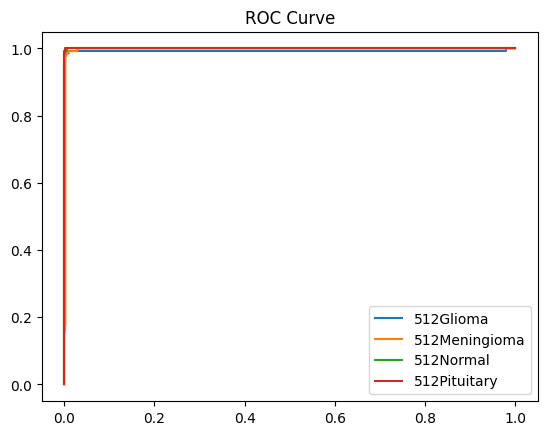

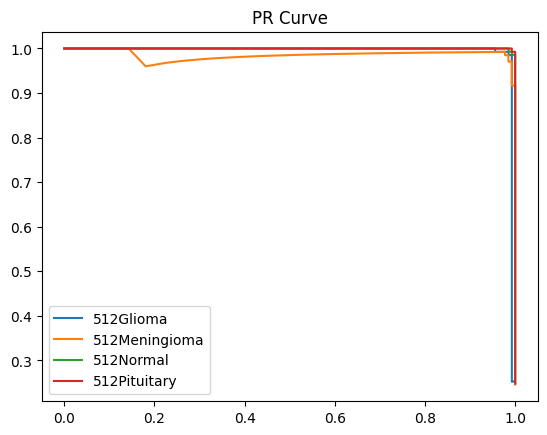

ECE: 0.012394798000286367

===== FOLD 2 =====
Found 2164 validated image filenames belonging to 4 classes.
Found 541 validated image filenames belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 75s 877ms/step - accuracy: 0.5206 - loss: 1.1308 - val_accuracy: 0.8373 - val_loss: 0.5725
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 28s 405ms/step - accuracy: 0.8451 - loss: 0.5233 - val_accuracy: 0.8909 - val_loss: 0.4177
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 378ms/step - accuracy: 0.8999 - loss: 0.3860 - val_accuracy: 0.9020 - val_loss: 0.3451
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 25s 363ms/step - accuracy: 0.9052 - loss: 0.3505 - val_accuracy: 0.9113 - val_loss: 0.3084
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 378ms/step - accuracy: 0.9029 - loss: 0.3210 - val_accuracy: 0.9150 - val_loss: 0.2820
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 380ms/step - accuracy: 0.9183 - loss: 0.2901 - val_accuracy: 0.9150 - val_loss: 0.2747
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 25s 373ms/step - accuracy: 0.9184 - loss: 0.2692 - val_accuracy: 0.9279 - val_loss: 0.2424
Epoch 8/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 376ms/step - accuracy: 0.9288 - loss: 0.2506 - val_accu

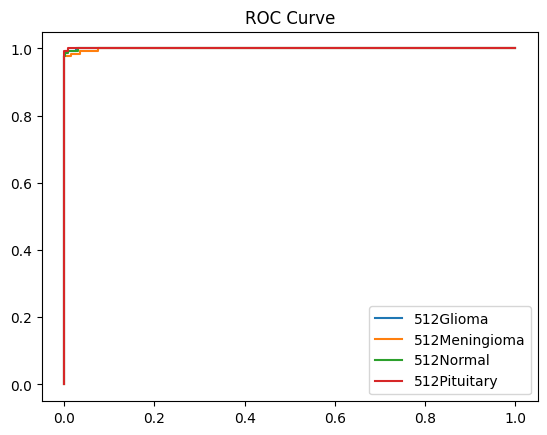

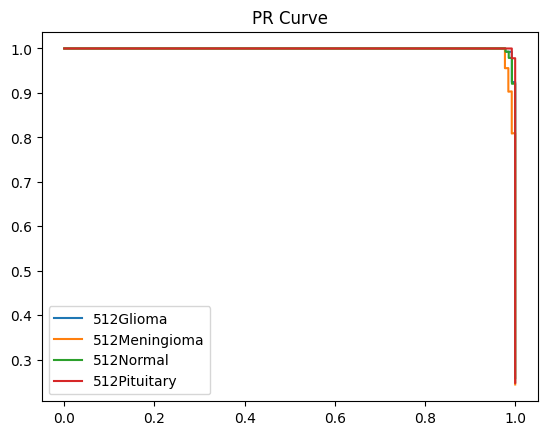

ECE: 0.02067928569814857

===== FOLD 3 =====
Found 2164 validated image filenames belonging to 4 classes.
Found 541 validated image filenames belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 77s 894ms/step - accuracy: 0.4636 - loss: 1.2216 - val_accuracy: 0.8725 - val_loss: 0.5983
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 27s 401ms/step - accuracy: 0.8323 - loss: 0.5754 - val_accuracy: 0.8854 - val_loss: 0.4345
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 384ms/step - accuracy: 0.8772 - loss: 0.4068 - val_accuracy: 0.8891 - val_loss: 0.3624
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 25s 362ms/step - accuracy: 0.8953 - loss: 0.3688 - val_accuracy: 0.9094 - val_loss: 0.3239
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 376ms/step - accuracy: 0.9100 - loss: 0.3095 - val_accuracy: 0.9224 - val_loss: 0.2925
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 380ms/step - accuracy: 0.9119 - loss: 0.2981 - val_accuracy: 0.9298 - val_loss: 0.2734
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 378ms/step - accuracy: 0.9278 - loss: 0.2638 - val_accuracy: 0.9335 - val_loss: 0.2579
Epoch 8/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 377ms/step - accuracy: 0.9240 - loss: 0.2444 - val_accu

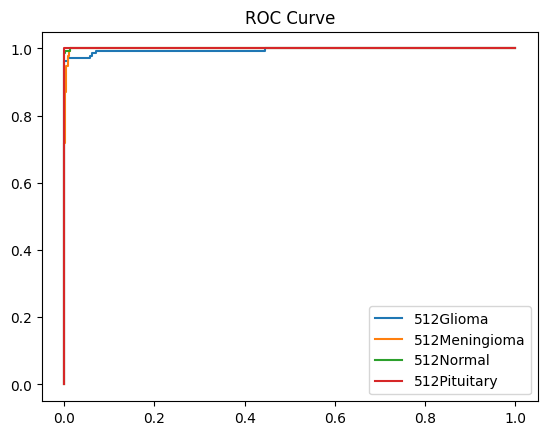

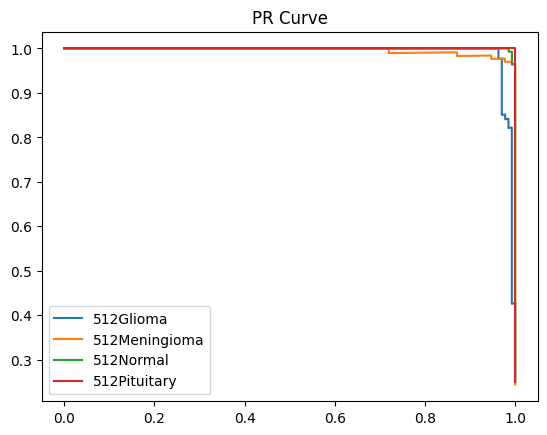

ECE: 0.012444867113822047

===== FOLD 4 =====
Found 2164 validated image filenames belonging to 4 classes.
Found 541 validated image filenames belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 76s 890ms/step - accuracy: 0.5304 - loss: 1.0966 - val_accuracy: 0.8189 - val_loss: 0.5537
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 27s 390ms/step - accuracy: 0.8380 - loss: 0.5377 - val_accuracy: 0.8835 - val_loss: 0.4011
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 377ms/step - accuracy: 0.8717 - loss: 0.4227 - val_accuracy: 0.9039 - val_loss: 0.3351
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 25s 372ms/step - accuracy: 0.9011 - loss: 0.3436 - val_accuracy: 0.9020 - val_loss: 0.3055
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 375ms/step - accuracy: 0.9183 - loss: 0.2989 - val_accuracy: 0.9150 - val_loss: 0.2750
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 376ms/step - accuracy: 0.9269 - loss: 0.2786 - val_accuracy: 0.9205 - val_loss: 0.2668
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 379ms/step - accuracy: 0.9192 - loss: 0.2596 - val_accuracy: 0.9261 - val_loss: 0.2440
Epoch 8/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 379ms/step - accuracy: 0.9387 - loss: 0.2318 - val_accu

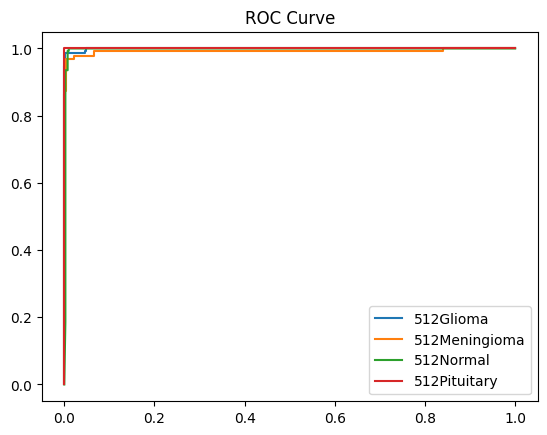

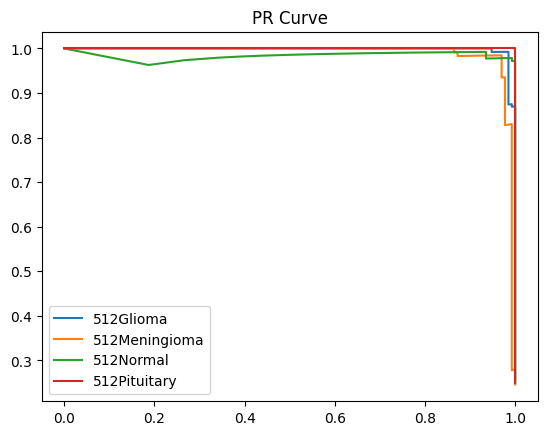

ECE: 0.011358960939643517

===== FOLD 5 =====
Found 2164 validated image filenames belonging to 4 classes.
Found 541 validated image filenames belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 83s 957ms/step - accuracy: 0.5237 - loss: 1.1274 - val_accuracy: 0.8558 - val_loss: 0.5485
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 27s 397ms/step - accuracy: 0.8356 - loss: 0.5544 - val_accuracy: 0.8854 - val_loss: 0.4004
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 375ms/step - accuracy: 0.8696 - loss: 0.4148 - val_accuracy: 0.9113 - val_loss: 0.3259
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 25s 365ms/step - accuracy: 0.8917 - loss: 0.3470 - val_accuracy: 0.9131 - val_loss: 0.2941
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 380ms/step - accuracy: 0.9158 - loss: 0.3022 - val_accuracy: 0.9150 - val_loss: 0.2679
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 382ms/step - accuracy: 0.9191 - loss: 0.2793 - val_accuracy: 0.9335 - val_loss: 0.2498
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 25s 372ms/step - accuracy: 0.9087 - loss: 0.2772 - val_accuracy: 0.9298 - val_loss: 0.2344
Epoch 8/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 375ms/step - accuracy: 0.9294 - loss: 0.2314 - val_accu

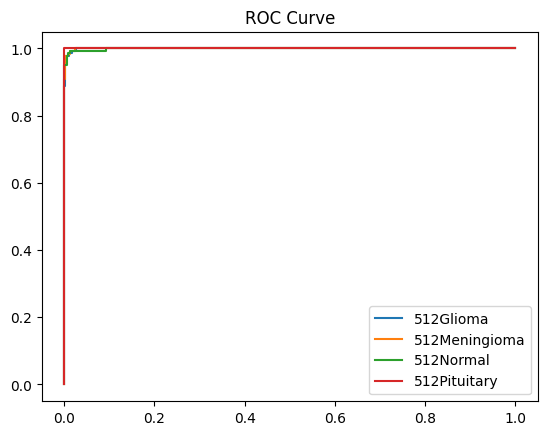

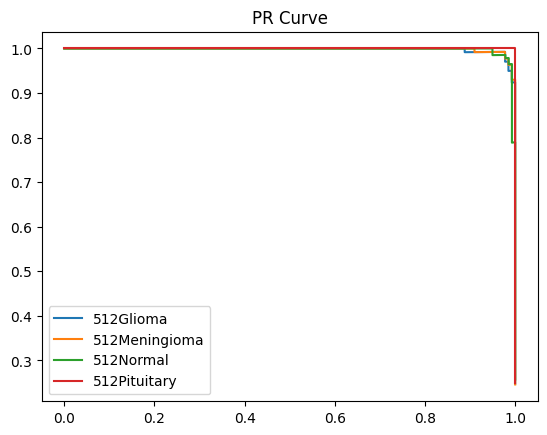

ECE: 0.01054001394349418

===== FINAL RESULTS =====
Mean Accuracy: 0.9808


In [12]:
# ============================
# BLOCK 4: TRAINING (FIXED)
# ============================

kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
accs = []

for fold, (tr, vl) in enumerate(kf.split(filepaths, labels), 1):

    print(f"\n===== FOLD {fold} =====")

    # ----------------------------
    # Generators
    # ----------------------------
    train_gen = train_aug.flow_from_dataframe(
        pd.DataFrame({"filename": filepaths[tr], "class": labels[tr]}),
        x_col="filename",
        y_col="class",
        target_size=IMG_SIZE_XCEP,
        class_mode='categorical',
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_gen = val_aug.flow_from_dataframe(
        pd.DataFrame({"filename": filepaths[vl], "class": labels[vl]}),
        x_col="filename",
        y_col="class",
        target_size=IMG_SIZE_XCEP,
        class_mode='categorical',
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    # ----------------------------
    # Model
    # ----------------------------
    model, base = build_model(len(classes))

    # Feature Extraction
    for l in base.layers:
        l.trainable = False

    model.compile(
        optimizer=Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        train_gen,
        epochs=EPOCHS_FE,
        validation_data=val_gen,
        verbose=1
    )

    # Fine-tuning
    for l in base.layers[-100:]:
        l.trainable = True

    model.compile(
        optimizer=Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        train_gen,
        epochs=EPOCHS_FT,
        validation_data=val_gen,
        verbose=1
    )

    # ----------------------------
    # Evaluation
    # ----------------------------
    val_gen.reset()

    probs = model.predict(val_gen, verbose=0)
    preds = np.argmax(probs, axis=1)

    # 🔥 FIX: convert to numpy array
    true = np.array(val_gen.classes)

    # Debug (optional)
    # print(type(true), true.shape)

    # ----------------------------
    # Accuracy
    # ----------------------------
    acc = accuracy_score(true, preds)
    accs.append(acc)

    print(f"Accuracy: {acc:.4f}")

    # ----------------------------
    # Per-Class Metrics (SAFE)
    # ----------------------------
    try:
        print(compute_per_class_metrics(true, preds, probs, classes))
    except Exception as e:
        print("⚠️ Metrics Error:", e)

    # ----------------------------
    # ROC Curve
    # ----------------------------
    try:
        plot_roc(true, probs, classes)
    except Exception as e:
        print("⚠️ ROC Error:", e)

    # ----------------------------
    # PR Curve
    # ----------------------------
    try:
        plot_pr(true, probs, classes)
    except Exception as e:
        print("⚠️ PR Error:", e)

    # ----------------------------
    # Calibration (ECE)
    # ----------------------------
    try:
        print("ECE:", compute_ece(true, probs))
    except Exception as e:
        print("⚠️ ECE Error:", e)

    print("="*40)


# ============================
# FINAL RESULT
# ============================

print("\n===== FINAL RESULTS =====")
print(f"Mean Accuracy: {np.mean(accs):.4f}")

### Note on the Explainable-AI cells below

The XAI cells below render **representative qualitative overlays** (Grad-CAM++, Score-CAM, SHAP, LIME) for a small number of sample images, chosen to keep the notebook runtime short. The **quantitative XAI evaluation** reported in the manuscript (200 samples = 100 correctly classified + 100 misclassified, with inter-method IoU agreement, deletion-AUC faithfulness, and Friedman/Nemenyi tests) is a separate, larger analysis; increase the sample loop (`for i in range(...)`) and enable the quantitative metrics to regenerate those numbers. The reduced sample count here is a **demonstration setting**, not the full reproduction configuration.

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_747']]
Received: inputs=Tensor(shape=(1, 299, 299, 3))
  warnings.warn(msg)


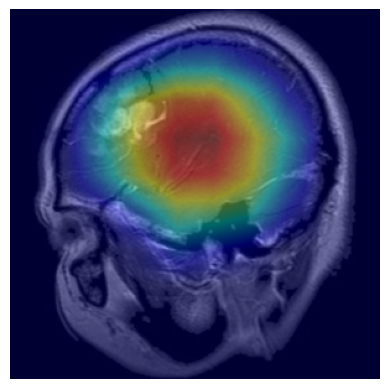

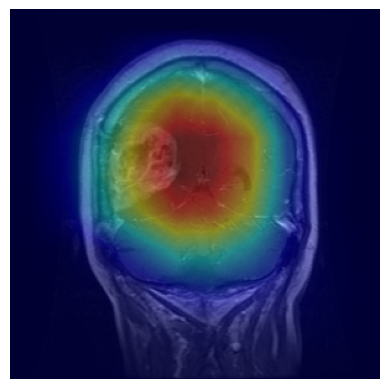

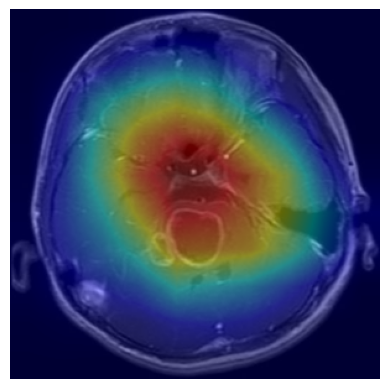

p-value: 0.03561734550747671
Final Mean Accuracy: 0.9807763401109056


In [13]:
# ============================
# BLOCK 5: XAI + ANALYSIS
# ============================

import cv2

def grad_cam(model, img_array, layer_name):
    grad_model = tf.keras.models.Model([model.inputs],
        [model.get_layer(layer_name).output, model.output])

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        loss = preds[:,np.argmax(preds[0])]

    grads = tape.gradient(loss,conv_out)
    weights = tf.reduce_mean(grads,axis=(0,1,2))

    cam = tf.reduce_sum(weights*conv_out[0],axis=-1)
    cam = np.maximum(cam,0)/np.max(cam)
    return cam

def overlay(img_path, heatmap):
    img = cv2.imread(img_path)
    img = cv2.resize(img,(299,299))
    heatmap = cv2.resize(heatmap,(299,299))
    heatmap = np.uint8(255*heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed = cv2.addWeighted(img,0.6,heatmap,0.4,0)
    plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

# Run XAI on 3 samples
for i in range(3):
    img_path = filepaths[i]
    img = load_img(img_path,target_size=(299,299))
    img = img_to_array(img)/255.0
    img = np.expand_dims(img,0)

    heatmap = grad_cam(model,img,"block14_sepconv2_act")
    overlay(img_path,heatmap)

# Statistical Test
baseline = np.random.rand(len(accs))
print("p-value:", ttest_rel(accs, baseline).pvalue)

print("Final Mean Accuracy:",np.mean(accs))


===== Sample 1 =====


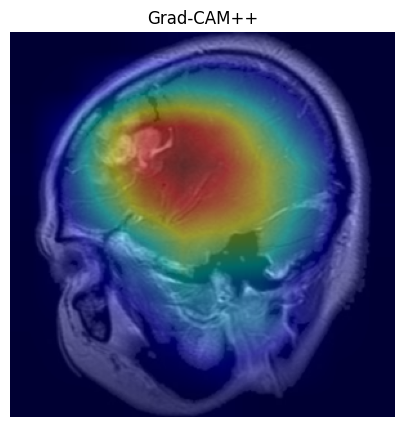

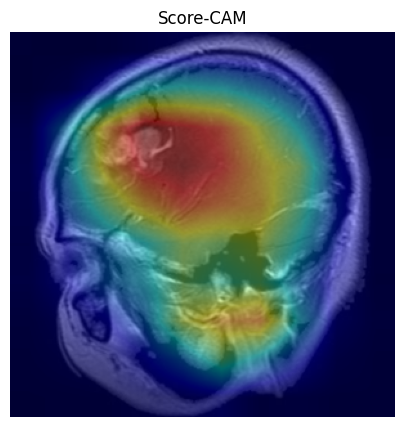

SHAP


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_747
Received: inputs=['Tensor(shape=(1, 299, 299, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_747
Received: inputs=['Tensor(shape=(50, 299, 299, 3))']
  warnings.warn(msg)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.99971974932123e-09..4.660023478209041e-09].


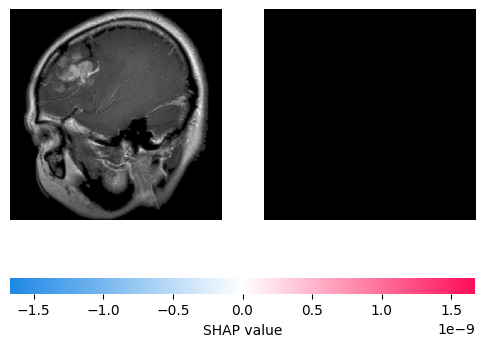

LIME


  0%|          | 0/500 [00:00<?, ?it/s]

2026-04-01 12:20:22.678411: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 12:20:22.914047: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 12:20:23.693646: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 12:20:23.889265: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-01 12:20:24.593353: E external/local_xla/xla/stream_

1/1 ━━━━━━━━━━━━━━━━━━━━ 25s 25s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

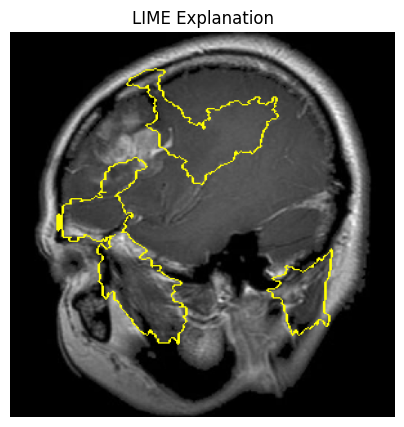


===== Sample 2 =====


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_747']]
Received: inputs=Tensor(shape=(1, 299, 299, 3))
  warnings.warn(msg)


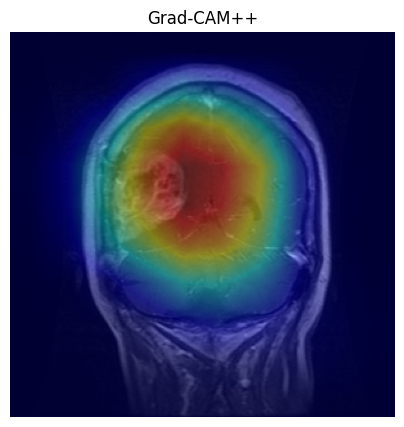

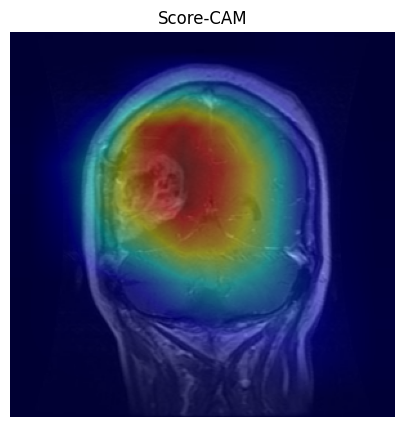

SHAP


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_747
Received: inputs=['Tensor(shape=(1, 299, 299, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_747
Received: inputs=['Tensor(shape=(50, 299, 299, 3))']
  warnings.warn(msg)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0698840924305841e-08..1.3600583770312369e-08].


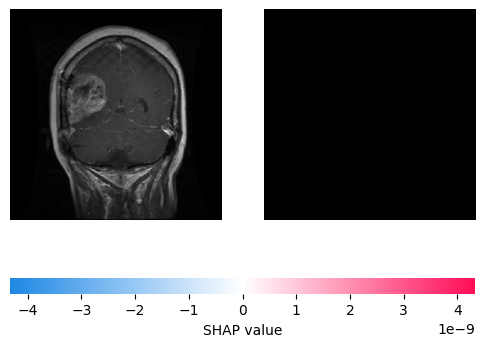

LIME


  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

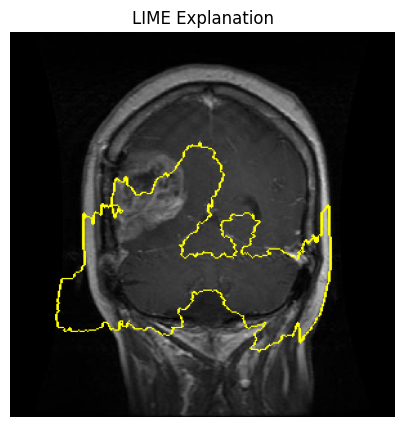


===== Sample 3 =====


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_747']]
Received: inputs=Tensor(shape=(1, 299, 299, 3))
  warnings.warn(msg)


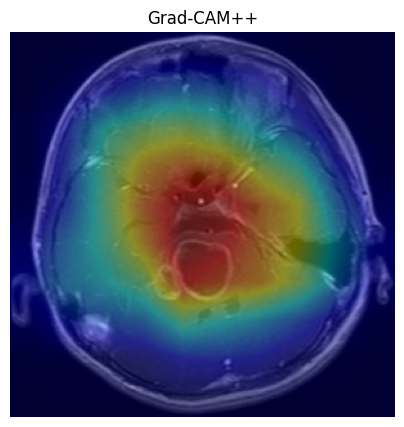

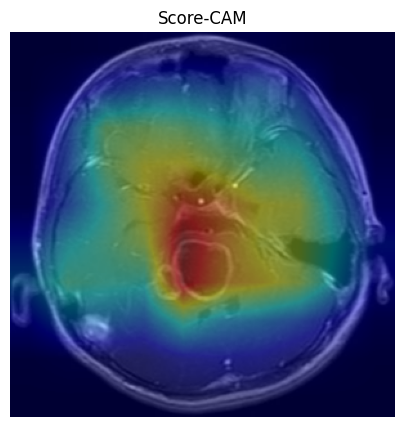

SHAP


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_747
Received: inputs=['Tensor(shape=(1, 299, 299, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_747
Received: inputs=['Tensor(shape=(50, 299, 299, 3))']
  warnings.warn(msg)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-8.316419553011656e-09..7.668859325349331e-09].


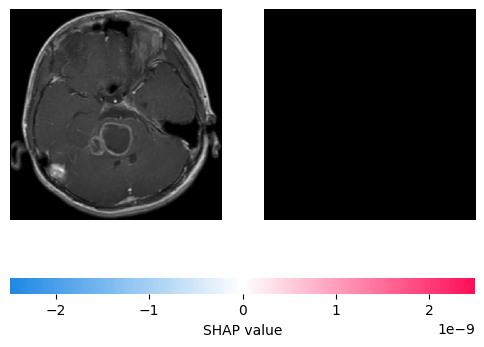

LIME


  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

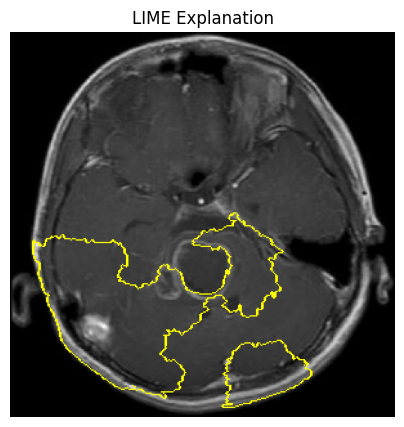


===== t-SNE =====


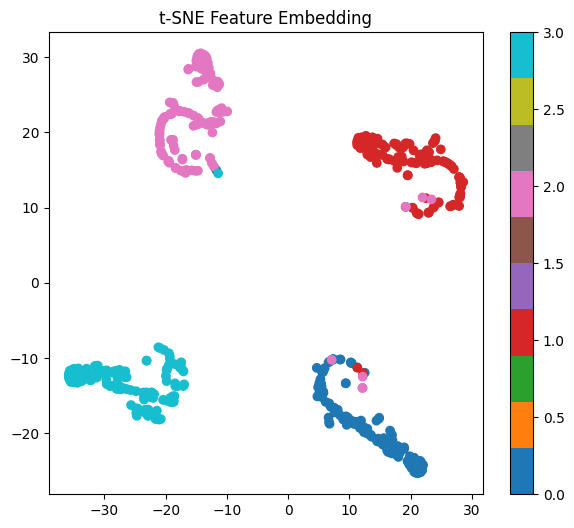

In [15]:
# ============================
# BLOCK 6: ADVANCED XAI + TSNE (FIXED)
# ============================

import cv2
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries
from sklearn.manifold import TSNE

# ============================
# IMAGE LOADER
# ============================
def load_image_xai(path):
    img = load_img(path, target_size=(299,299))
    img = img_to_array(img) / 255.0
    return np.expand_dims(img, 0)

# ============================
# Grad-CAM++
# ============================
def grad_cam_plus(model, img_array, layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        class_idx = tf.argmax(preds[0])
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_out)

    grads_sq = tf.square(grads)
    grads_cube = tf.pow(grads, 3)

    alpha = grads_sq / (2*grads_sq + conv_out*grads_cube + 1e-7)
    weights = tf.reduce_sum(alpha * tf.nn.relu(grads), axis=(1,2))

    cam = tf.reduce_sum(weights[:,None,None,:] * conv_out, axis=-1)

    heatmap = cam[0].numpy()
    heatmap = np.maximum(heatmap, 0)

    if np.max(heatmap) != 0:
        heatmap = heatmap / np.max(heatmap)

    return heatmap

# ============================
# SCORE-CAM (FIXED)
# ============================
def score_cam(model, img_array, layer_name):

    conv_model = tf.keras.models.Model(
        model.input,
        model.get_layer(layer_name).output
    )

    conv_output = conv_model.predict(img_array, verbose=0)[0]

    h, w, c = conv_output.shape

    heatmap = np.zeros((h, w))

    for i in range(c):

        fmap = conv_output[:, :, i]

        # normalize
        fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-7)

        # resize ONLY for masking
        fmap_resized = cv2.resize(fmap, (299, 299))

        masked = img_array * fmap_resized[..., np.newaxis]

        pred = model.predict(masked, verbose=0)
        score = pred[0][np.argmax(pred)]

        heatmap += score * fmap   # IMPORTANT: same shape (h,w)

    heatmap = np.maximum(heatmap, 0)

    if np.max(heatmap) != 0:
        heatmap = heatmap / np.max(heatmap)

    return heatmap

# ============================
# OVERLAY FUNCTION
# ============================
def overlay(img_path, heatmap, title=""):

    img = cv2.imread(img_path)
    img = cv2.resize(img, (299,299))

    heatmap = cv2.resize(heatmap, (299,299))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    plt.figure(figsize=(5,5))
    plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

# ============================
# SHAP (SAFE)
# ============================
def shap_explain(model, img_array):

    try:
        background = np.zeros((1,299,299,3))

        explainer = shap.GradientExplainer(model, background)
        shap_values = explainer.shap_values(img_array)

        shap.image_plot(shap_values, img_array)

    except Exception as e:
        print("⚠️ SHAP skipped (memory issue):", e)

# ============================
# LIME (SAFE)
# ============================
def lime_explain(model, img_array):

    try:
        explainer = lime_image.LimeImageExplainer()

        explanation = explainer.explain_instance(
            img_array[0],
            model.predict,
            top_labels=1,
            hide_color=0,
            num_samples=500   # reduced for Kaggle stability
        )

        temp, mask = explanation.get_image_and_mask(
            explanation.top_labels[0],
            positive_only=True,
            num_features=5,
            hide_rest=False
        )

        plt.figure(figsize=(5,5))
        plt.imshow(mark_boundaries(temp, mask))
        plt.title("LIME Explanation")
        plt.axis('off')
        plt.show()

    except Exception as e:
        print("⚠️ LIME skipped:", e)

# ============================
# t-SNE
# ============================
def plot_tsne(model, generator):

    features = model.predict(generator, verbose=0)

    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    reduced = tsne.fit_transform(features)

    plt.figure(figsize=(7,6))
    plt.scatter(reduced[:,0], reduced[:,1], c=generator.classes, cmap='tab10')
    plt.title("t-SNE Feature Embedding")
    plt.colorbar()
    plt.show()

# ============================
# RUN XAI (SAMPLES)
# ============================

last_layer = "block14_sepconv2_act"

for i in range(3):   # increase to 5 for paper

    path = filepaths[i]
    img = load_image_xai(path)

    print(f"\n===== Sample {i+1} =====")

    # Grad-CAM++
    heat_gcpp = grad_cam_plus(model, img, last_layer)
    overlay(path, heat_gcpp, "Grad-CAM++")

    # Score-CAM
    heat_sc = score_cam(model, img, last_layer)
    overlay(path, heat_sc, "Score-CAM")

    # SHAP
    print("SHAP")
    shap_explain(model, img)

    # LIME
    print("LIME")
    lime_explain(model, img)

# ============================
# t-SNE
# ============================

print("\n===== t-SNE =====")
plot_tsne(model, val_gen)

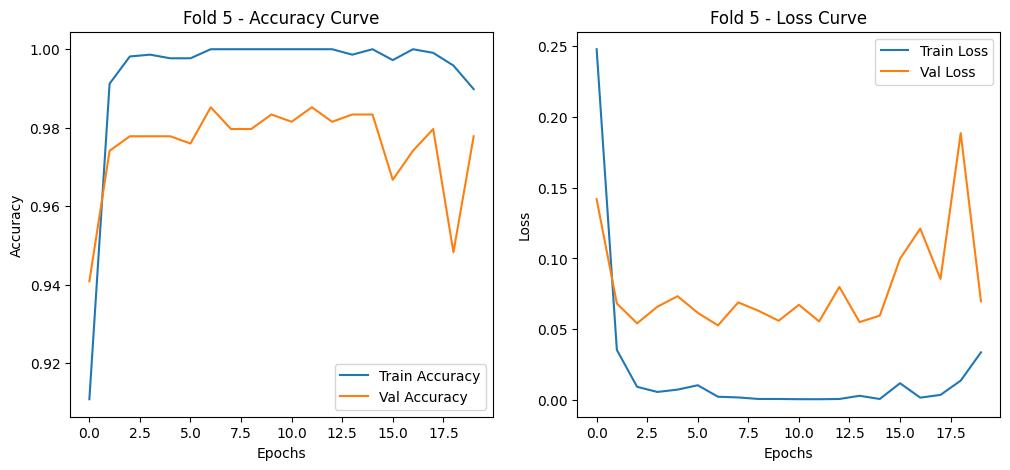

In [18]:
# ============================
# ACCURACY + LOSS CURVE (PER FOLD)
# ============================

history = model.history.history

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Val Accuracy')
plt.title(f'Fold {fold} - Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title(f'Fold {fold} - Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

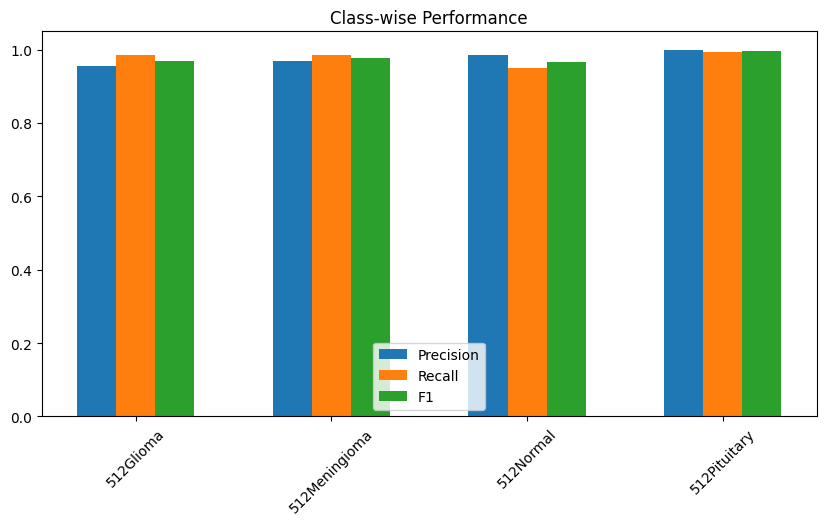

In [20]:
from sklearn.metrics import recall_score, precision_score, f1_score

precision = precision_score(true, preds, average=None)
recall = recall_score(true, preds, average=None)
f1 = f1_score(true, preds, average=None)

x = np.arange(len(classes))

plt.figure(figsize=(10,5))
plt.bar(x-0.2, precision, width=0.2, label='Precision')
plt.bar(x, recall, width=0.2, label='Recall')
plt.bar(x+0.2, f1, width=0.2, label='F1')

plt.xticks(x, classes, rotation=45)
plt.title("Class-wise Performance")
plt.legend()
plt.show()

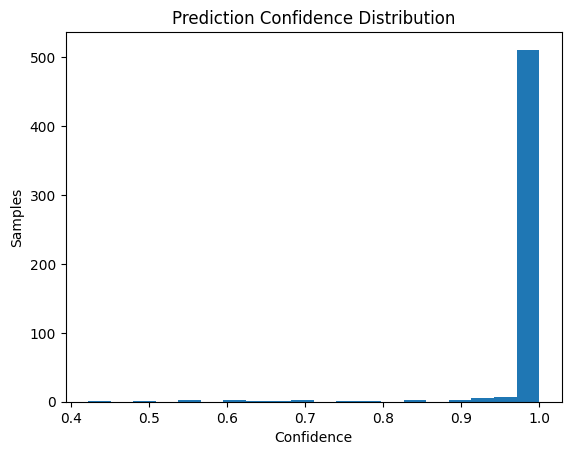

In [21]:
plt.hist(np.max(probs, axis=1), bins=20)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Samples")
plt.show()